In [1]:
from dataset import train_dataset, test_dataset, val_dataset, class_counts
from torch.utils.data import DataLoader
from models import CytologyClassifier
from models_testing import test_model, evaluate_classifier
from dataset import test_dataset
from torch.utils.data import DataLoader
import pandas as pd

In [2]:
kfold = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\wyniki_gridsearch.csv')
kfold

,architecture,lr,batch_size,epochs,mean_accuracy,std_accuracy,mean_f1,std_f1
0,resnet18,0.0010,16,20,87.762478,4.281390,0.792326,0.077431
1,resnet18,0.0010,32,20,90.169248,3.516106,0.823624,0.093170
2,resnet18,0.0001,16,20,93.032129,3.098935,0.876726,0.066062
3,resnet18,0.0001,32,20,91.838784,2.230302,0.848977,0.052843
4,vgg16,0.0010,16,20,91.368330,1.393699,0.838574,0.030689
5,vgg16,0.0010,32,20,90.172117,2.965010,0.822619,0.053519
6,vgg16,0.0001,16,20,91.606426,2.152618,0.846790,0.043074
7,vgg16,0.0001,32,20,91.127367,2.994067,0.839989,0.052899
8,custom_cnn,0.0010,16,20,72.403901,3.361647,0.638210,0.016194
9,custom_cnn,0.0010,32,20,80.321285,7.007228,0.741293,0.084138


## VGG

16, 0.0001, 50

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


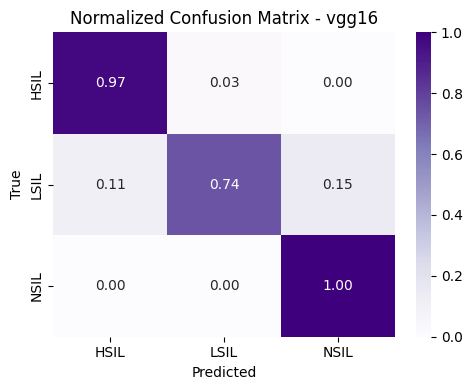

   Model  Accuracy  Precision    Recall  F1-score
0  vgg16   0.92233   0.926984  0.905247   0.91064
Classification report:
              precision    recall  f1-score   support

        HSIL       0.93      0.97      0.95        40
        LSIL       0.95      0.74      0.83        27
        NSIL       0.90      1.00      0.95        36

    accuracy                           0.92       103
   macro avg       0.93      0.91      0.91       103
weighted avg       0.92      0.92      0.92       103



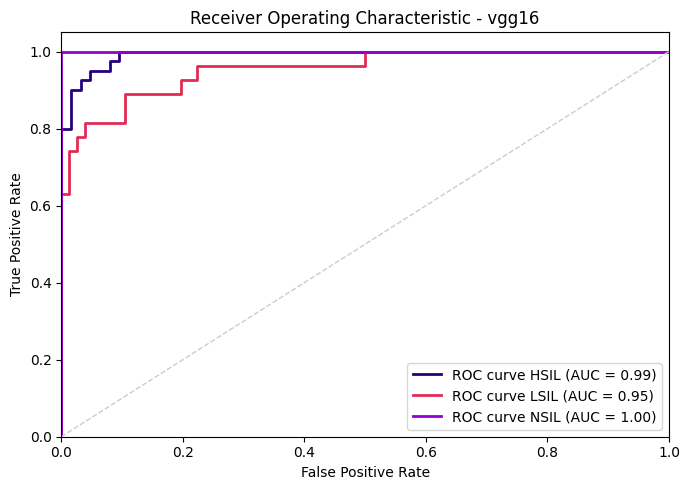

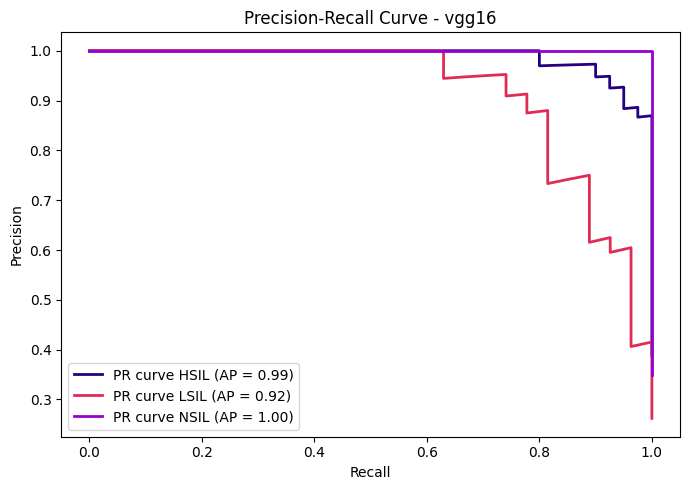

In [3]:
test_loader = DataLoader(test_dataset, batch_size=16)
test_model(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\vgg16\16_0_0001_50_0608.pth', test_loader, architecture='vgg16', model_label='vgg16')

In [4]:
evaluate_classifier(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\vgg16\16_0_0001_50_0608.pth', r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST', architecture='vgg16')

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== METRYKI (global) ===
Accuracy:            0.8621
Precision (macro):   0.8734
Recall    (macro):   0.8667
F1        (macro):   0.8586
Precision (weighted):0.8725
Recall    (weighted):0.8621
F1        (weighted):0.8555

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.7917    0.9500    0.8636        20
        LSIL     0.9286    0.6500    0.7647        20
        NSIL     0.9000    1.0000    0.9474        18

    accuracy                         0.8621        58
   macro avg     0.8734    0.8667    0.8586        58
weighted avg     0.8725    0.8621    0.8555        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL       0.95       0.05        0.0
true_LSIL       0.25       0.65        0.1
true_NSIL       0.00       0.00        1.0


32 0.0001 50

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


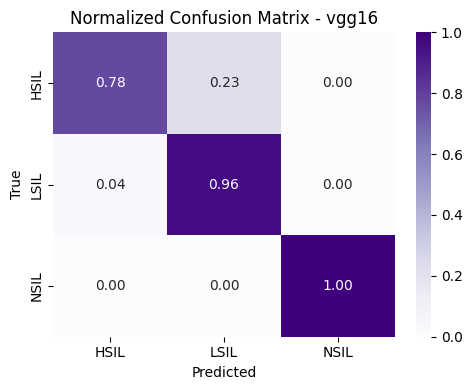

   Model  Accuracy  Precision    Recall  F1-score
0  vgg16  0.902913   0.903869  0.912654   0.89994
Classification report:
              precision    recall  f1-score   support

        HSIL       0.97      0.78      0.86        40
        LSIL       0.74      0.96      0.84        27
        NSIL       1.00      1.00      1.00        36

    accuracy                           0.90       103
   macro avg       0.90      0.91      0.90       103
weighted avg       0.92      0.90      0.90       103



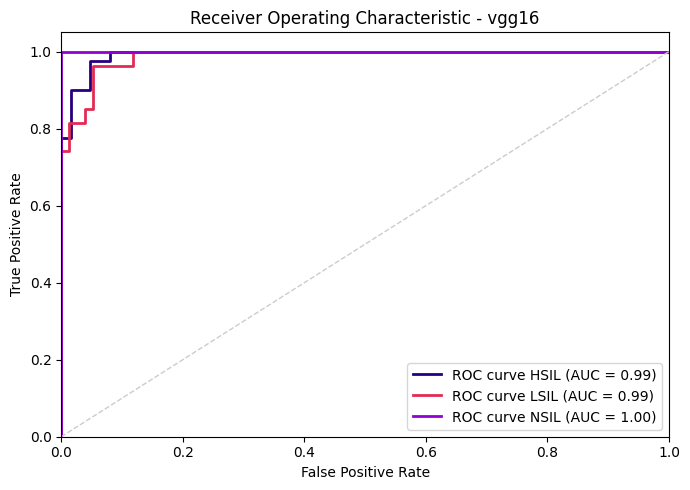

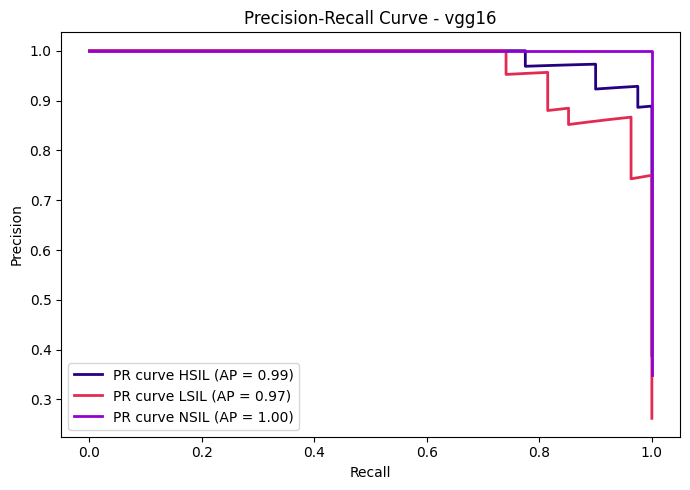

In [5]:
test_loader = DataLoader(test_dataset, batch_size=32)
test_model(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\vgg16\32_0_0001_50_0608.pth', test_loader, architecture='vgg16', model_label='vgg16')

In [6]:
evaluate_classifier(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\vgg16\32_0_0001_50_0608.pth', r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST', architecture='vgg16')

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== METRYKI (global) ===
Accuracy:            0.8966
Precision (macro):   0.9043
Recall    (macro):   0.8981
F1        (macro):   0.9001
Precision (weighted):0.9010
Recall    (weighted):0.8966
F1        (weighted):0.8977

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8947    0.8500    0.8718        20
        LSIL     0.8182    0.9000    0.8571        20
        NSIL     1.0000    0.9444    0.9714        18

    accuracy                         0.8966        58
   macro avg     0.9043    0.8981    0.9001        58
weighted avg     0.9010    0.8966    0.8977        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL       0.85   0.150000   0.000000
true_LSIL       0.10   0.900000   0.000000
true_NSIL       0.00   0.055556   0.944444


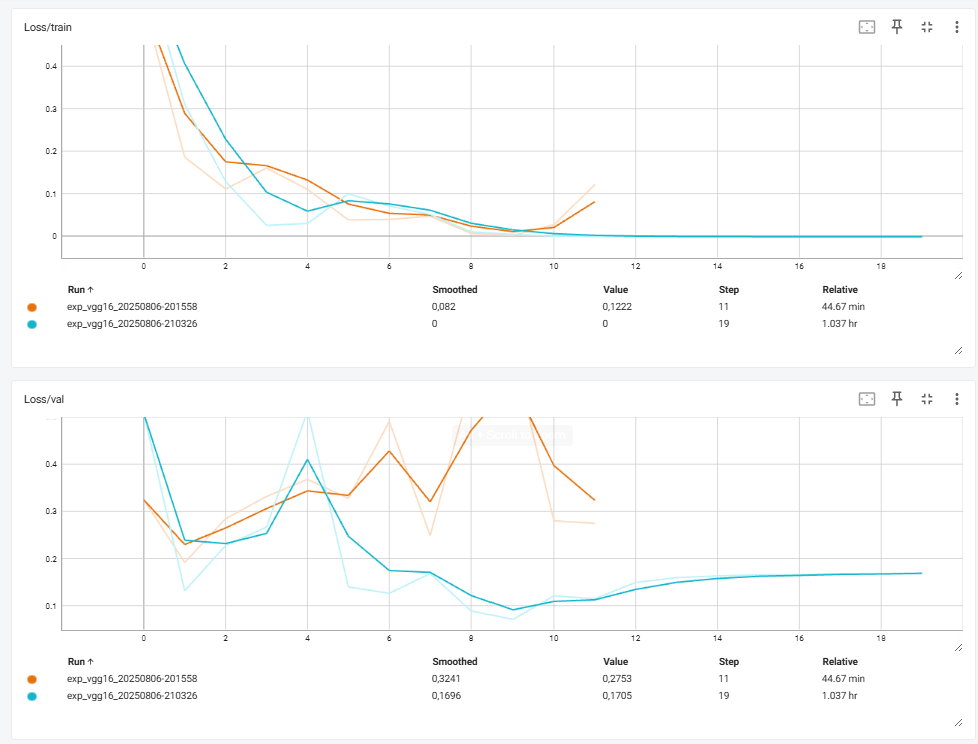

pomarańczowy = 16

## RESNET18

16 0.0001 50

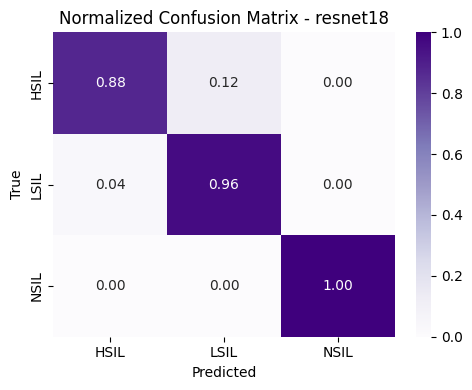

      Model  Accuracy  Precision    Recall  F1-score
0  resnet18  0.941748   0.936977  0.945988  0.939201
Classification report:
              precision    recall  f1-score   support

        HSIL       0.97      0.88      0.92        40
        LSIL       0.84      0.96      0.90        27
        NSIL       1.00      1.00      1.00        36

    accuracy                           0.94       103
   macro avg       0.94      0.95      0.94       103
weighted avg       0.95      0.94      0.94       103



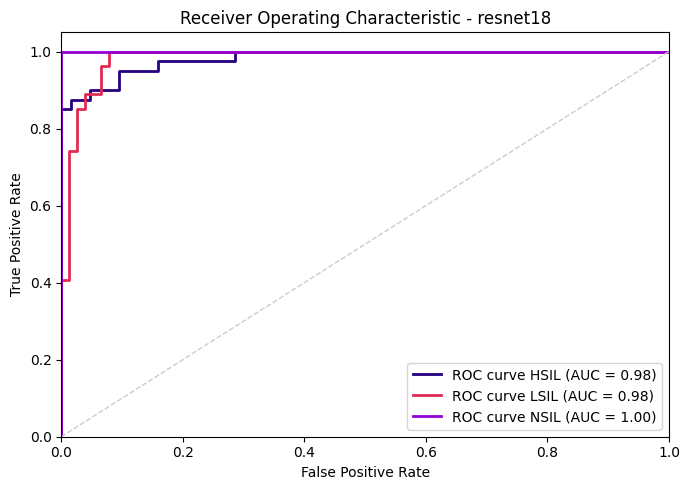

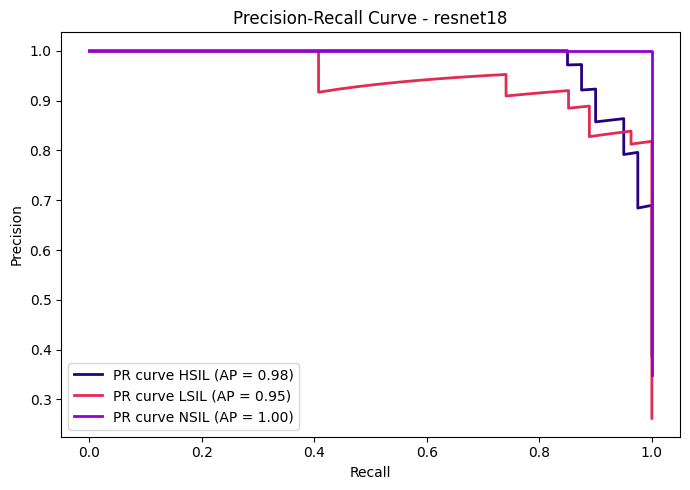

In [31]:
test_loader = DataLoader(test_dataset, batch_size=16)
test_model(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\resnet18\16_0_0001_50_1110.pth', test_loader, architecture='resnet18', model_label='resnet18')

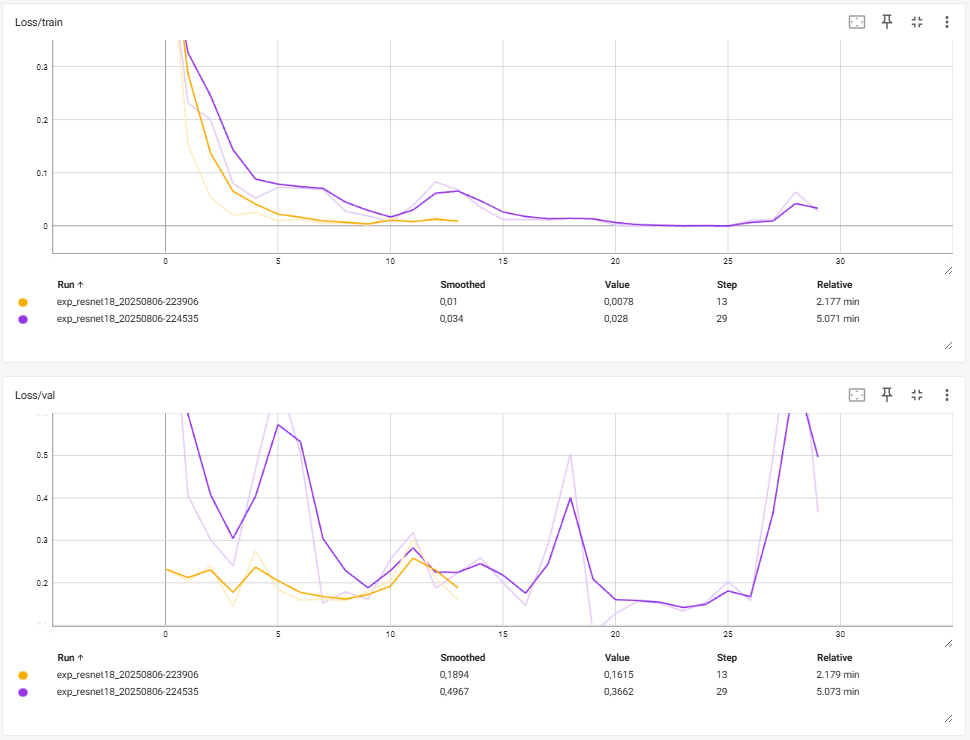

In [33]:
evaluate_classifier(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\resnet18\16_0_0001_50_1110.pth', r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST', architecture='resnet18')


=== METRYKI (global) ===
Accuracy:            0.9138
Precision (macro):   0.9269
Recall    (macro):   0.9167
F1        (macro):   0.9131
Precision (weighted):0.9262
Recall    (weighted):0.9138
F1        (weighted):0.9110

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8333    1.0000    0.9091        20
        LSIL     1.0000    0.7500    0.8571        20
        NSIL     0.9474    1.0000    0.9730        18

    accuracy                         0.9138        58
   macro avg     0.9269    0.9167    0.9131        58
weighted avg     0.9262    0.9138    0.9110        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL        1.0       0.00       0.00
true_LSIL        0.2       0.75       0.05
true_NSIL        0.0       0.00       1.00


fiolteowy = 0.001|

32 0.0001

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


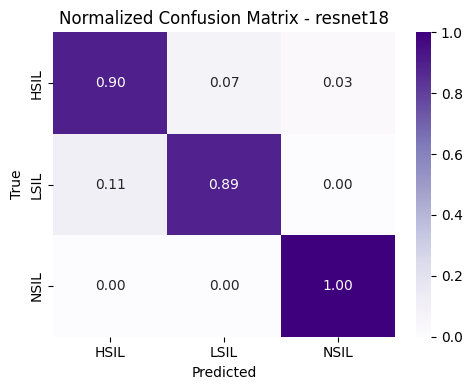

      Model  Accuracy  Precision   Recall  F1-score
0  resnet18  0.932039   0.928313  0.92963  0.928861
Classification report:
              precision    recall  f1-score   support

        HSIL       0.92      0.90      0.91        40
        LSIL       0.89      0.89      0.89        27
        NSIL       0.97      1.00      0.99        36

    accuracy                           0.93       103
   macro avg       0.93      0.93      0.93       103
weighted avg       0.93      0.93      0.93       103



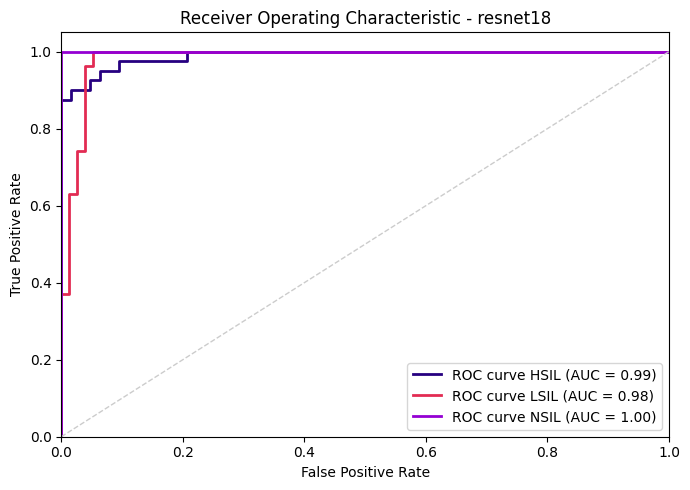

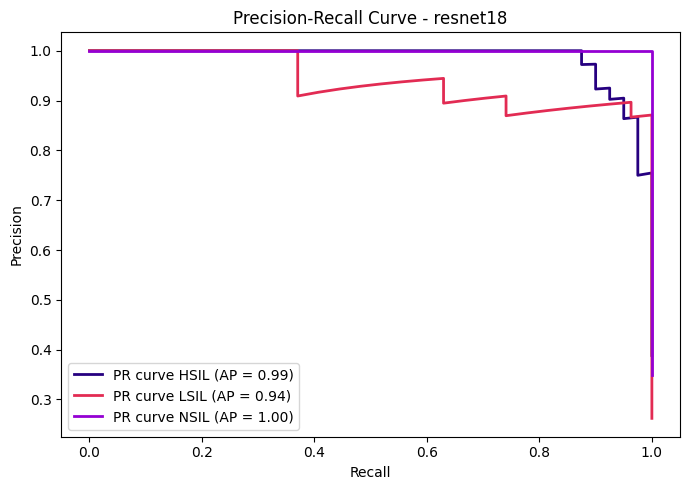

In [34]:
test_loader = DataLoader(test_dataset, batch_size=32)
test_model(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\resnet18\32_0_0001_50_0608.pth', test_loader, architecture='resnet18', model_label='resnet18')

In [35]:
evaluate_classifier(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\resnet18\32_0_0001_50_0608.pth', r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST', architecture='resnet18')

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== METRYKI (global) ===
Accuracy:            0.9138
Precision (macro):   0.9173
Recall    (macro):   0.9167
F1        (macro):   0.9166
Precision (weighted):0.9144
Recall    (weighted):0.9138
F1        (weighted):0.9137

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8571    0.9000    0.8780        20
        LSIL     0.8947    0.8500    0.8718        20
        NSIL     1.0000    1.0000    1.0000        18

    accuracy                         0.9138        58
   macro avg     0.9173    0.9167    0.9166        58
weighted avg     0.9144    0.9138    0.9137        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL       0.90       0.10        0.0
true_LSIL       0.15       0.85        0.0
true_NSIL       0.00       0.00        1.0


 ## CNN

16 lr 0.0001 epochs 50 

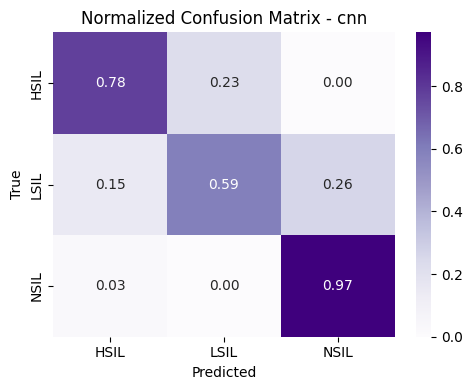

  Model  Accuracy  Precision    Recall  F1-score
0   cnn  0.796117   0.778148  0.779938  0.776203
Classification report:
              precision    recall  f1-score   support

        HSIL       0.86      0.78      0.82        40
        LSIL       0.64      0.59      0.62        27
        NSIL       0.83      0.97      0.90        36

    accuracy                           0.80       103
   macro avg       0.78      0.78      0.78       103
weighted avg       0.79      0.80      0.79       103



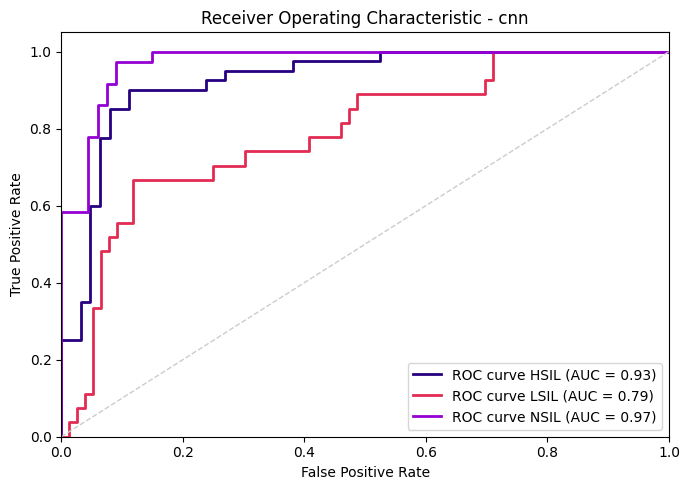

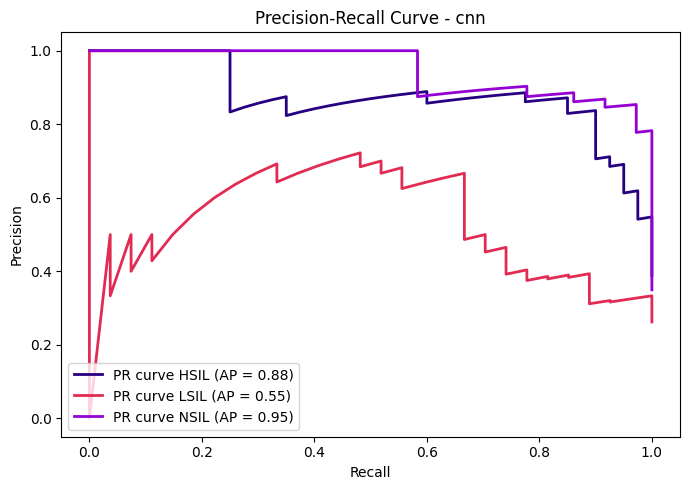

In [36]:
test_loader = DataLoader(test_dataset, batch_size=16)
test_model(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\custom_cnn\16_0_0001_50_1110.pth', test_loader, architecture='custom_cnn', model_label='cnn')

In [37]:
evaluate_classifier(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\custom_cnn\16_0_0001_50_1110.pth', r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST', architecture='custom_cnn')


=== METRYKI (global) ===
Accuracy:            0.7414
Precision (macro):   0.7409
Recall    (macro):   0.7444
F1        (macro):   0.7405
Precision (weighted):0.7392
Recall    (weighted):0.7414
F1        (weighted):0.7380

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.7273    0.8000    0.7619        20
        LSIL     0.7059    0.6000    0.6486        20
        NSIL     0.7895    0.8333    0.8108        18

    accuracy                         0.7414        58
   macro avg     0.7409    0.7444    0.7405        58
weighted avg     0.7392    0.7414    0.7380        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL   0.800000   0.200000   0.000000
true_LSIL   0.200000   0.600000   0.200000
true_NSIL   0.111111   0.055556   0.833333


 32 lr 0.0001 epochs 50 


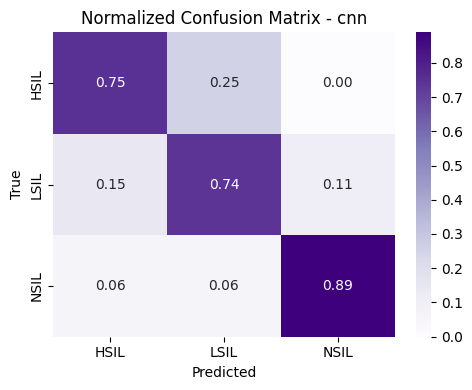

  Model  Accuracy  Precision   Recall  F1-score
0   cnn  0.796117   0.790873  0.79321  0.789616
Classification report:
              precision    recall  f1-score   support

        HSIL       0.83      0.75      0.79        40
        LSIL       0.62      0.74      0.68        27
        NSIL       0.91      0.89      0.90        36

    accuracy                           0.80       103
   macro avg       0.79      0.79      0.79       103
weighted avg       0.81      0.80      0.80       103



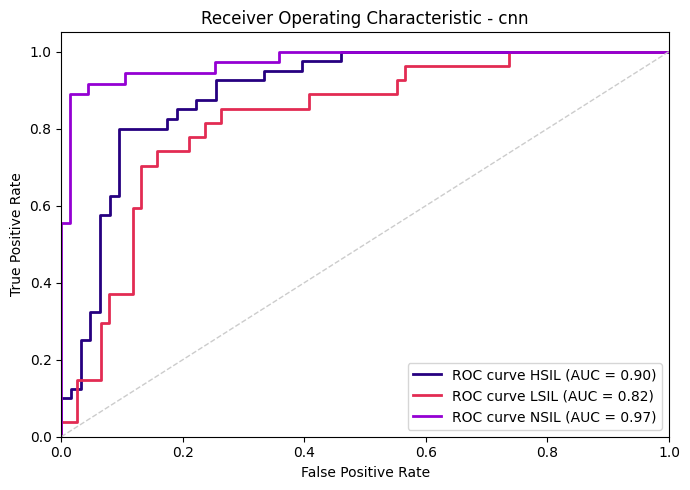

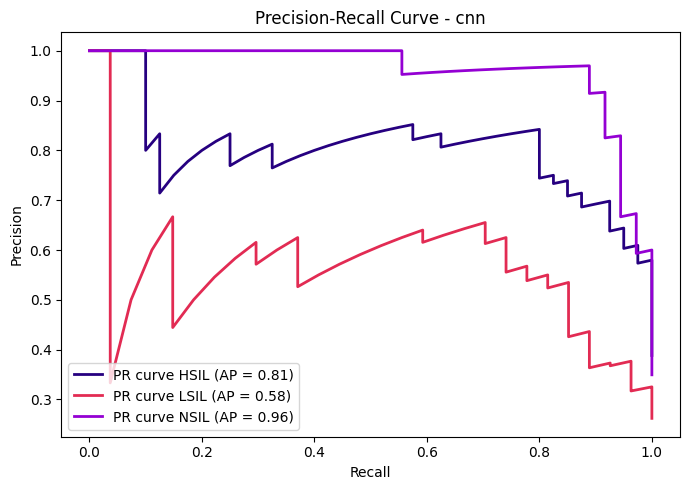

In [13]:
test_loader = DataLoader(test_dataset, batch_size=16)
test_model(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\custom_cnn\32_0_0001_50_0908.pth', test_loader, architecture='custom_cnn', model_label='cnn')

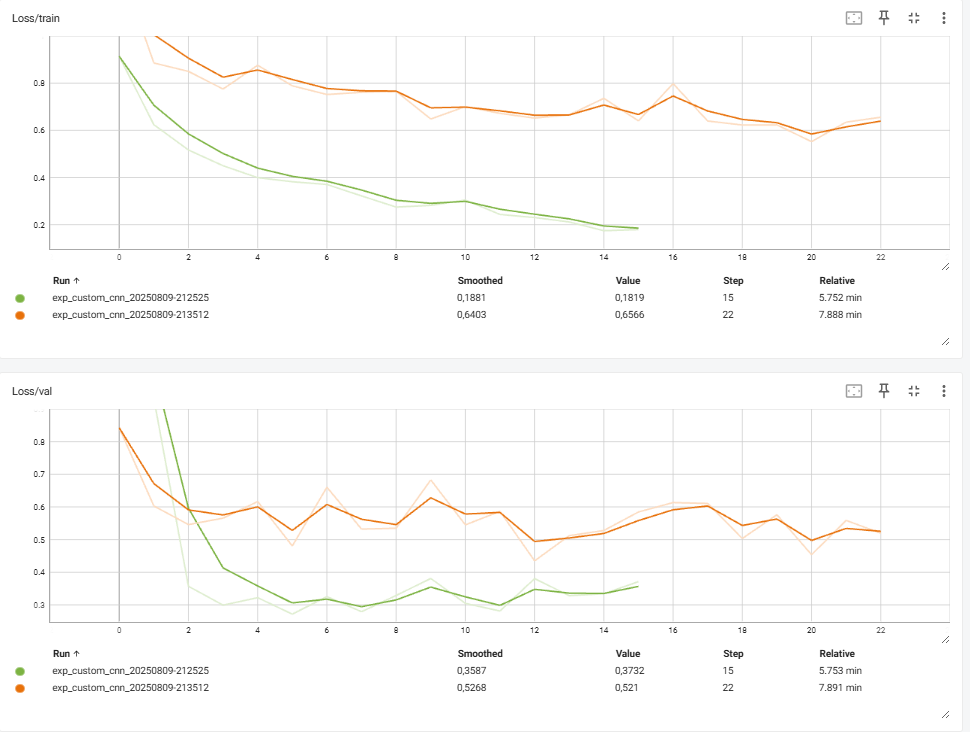

In [17]:
evaluate_classifier(r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\custom_cnn\32_0_0001_50_0908.pth', r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST', architecture='custom_cnn')


=== METRYKI (global) ===
Accuracy:            0.8103
Precision (macro):   0.8270
Recall    (macro):   0.8111
F1        (macro):   0.8130
Precision (weighted):0.8232
Recall    (weighted):0.8103
F1        (weighted):0.8106

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.8235    0.7000    0.7568        20
        LSIL     0.7200    0.9000    0.8000        20
        NSIL     0.9375    0.8333    0.8824        18

    accuracy                         0.8103        58
   macro avg     0.8270    0.8111    0.8130        58
weighted avg     0.8232    0.8103    0.8106        58


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL   0.700000   0.300000   0.000000
true_LSIL   0.050000   0.900000   0.050000
true_NSIL   0.111111   0.055556   0.833333
